# Pairs Trading: Coca-Cola (KO) vs PepsiCo (PEP)

A statistical arbitrage strategy that trades the spread between two cointegrated stocks,
progressing from a simple static baseline to an adaptive Kalman-filter approach.

**This notebook is the consolidated, narrative version of the project.** It walks through
the reasoning end-to-end: data → cointegration test → three signal-generation approaches →
comparison → conclusions. Code here calls directly into the `src/` package.

- Full implementation: [`src/`](../src)
- Original exploratory / experiment notebooks: [`notebooks/`](.)

> **Note on this version.** An earlier version of `signals_rolling.py` had a same-bar
> lookahead bug: `generate_positions` recorded a position *after* reacting to the current
> bar's z-score, so a signal from today's z-score could trade at today's price. That's been
> fixed — positions are now recorded *before* acting on the current bar, so a signal only
> takes effect from the next bar onward (matching the convention `signals_kalman_ou.py`
> already used). This affects the **Rolling OLS baseline** and the **Kalman-only** strategy
> (both use `signals_rolling.generate_positions`); the **Kalman + OU** strategy was already
> correct and is unchanged. Numbers below reflect the fix — both affected strategies got
> meaningfully worse, which is itself the headline finding of this iteration.

**Why KO and PEP?** Coca-Cola and PepsiCo are close economic substitutes — same industry,
overlapping demand drivers, similar market cap tier — which makes them a textbook candidate
pair for a mean-reversion / statistical-arbitrage strategy.

**Strategies covered:**
1. Rolling Ordinary Least Squares (OLS) hedge ratio + rolling z-score (baseline)
2. Kalman filter hedge ratio + OU-derived dynamic z-score window
3. Kalman filter hedge ratio + fixed rolling z-score (best performer)


## Setup

In [ ]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller

from src.data import download_prices, get_log_prices
from src.signals_rolling import (
    rolling_hedge_ratio,
    compute_rolling_spread,
    compute_rolling_zscore,
    generate_positions as generate_positions_rolling,  # lookahead-fixed version
)
from src.signals_kalman_ou import (
    kalman_hedge_ratio,
    compute_kalman_spread,
    run_kalman_ou_pipeline,
    generate_positions as generate_positions_kalman,
)
from src.backtest import run_backtest
from src.metrics import summarize_results

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## 1. Data Loading

Daily adjusted close prices for KO and PEP, 2015–2022 (~8 years, `~2014` trading days).
`auto_adjust=True` in `yfinance` handles dividends and splits so raw price differences are
directly comparable.

In [ ]:
TICKERS = ["KO", "PEP"]
START   = "2015-01-01"
END     = "2022-12-31"

prices     = download_prices(TICKERS, start=START, end=END)
log_prices = get_log_prices(prices)

print(f"Loaded {len(prices)} bars | {prices.index[0].date()} -> {prices.index[-1].date()}")
prices.tail(3)

Loaded 2014 bars | 2015-01-02 -> 2022-12-30


Ticker             KO         PEP
Date                             
2022-12-28  57.318924  161.461044
2022-12-29  57.661564  161.665421
2022-12-30  57.355003  160.492737

## 2. Exploratory Analysis

Before testing for cointegration, it's worth just looking at the two series. Visually
similar long-run trends and a reasonably stable price ratio are a good sign that a
linear relationship might hold.

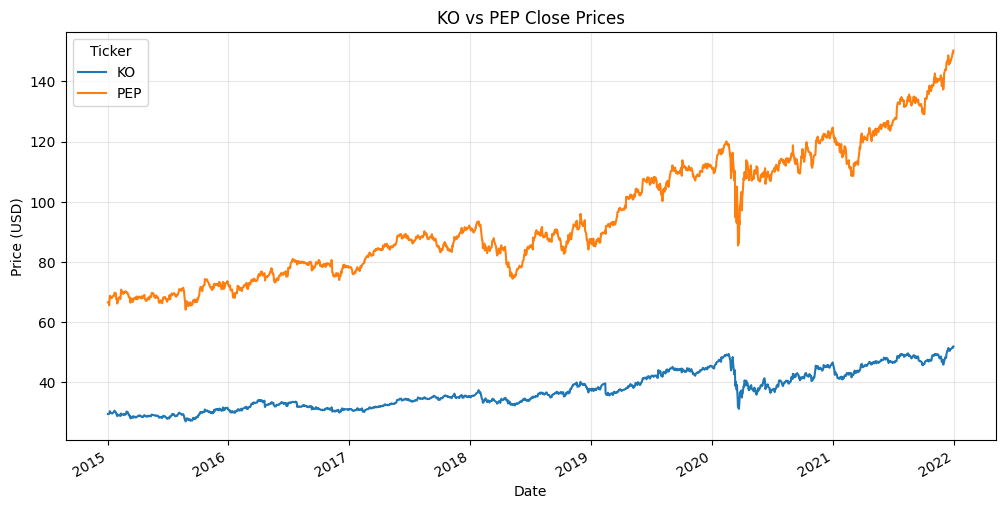

In [ ]:
close = prices
ax = close.plot(figsize=(12, 6), title="KO vs PEP Close Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.grid(alpha=0.3)
plt.show()

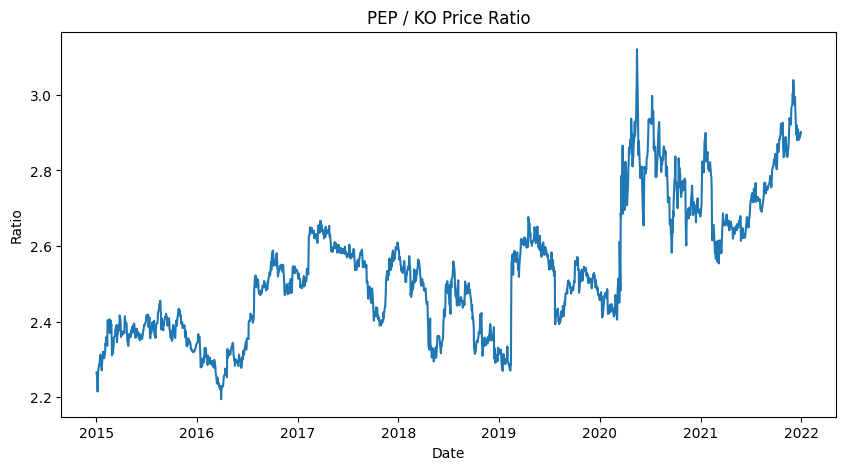

Correlation (levels): 0.9619258455239347


In [ ]:
ratio = prices["PEP"] / prices["KO"]
plt.figure(figsize=(10, 5))
plt.plot(ratio)
plt.title("PEP / KO Price Ratio")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.show()

print("Correlation (levels):", prices["PEP"].corr(prices["KO"]))

High correlation in price *levels* is common between any two trending stocks and is not
by itself evidence of a tradeable relationship — two totally unrelated stocks in a bull
market will look "correlated" this way. What we actually need is **cointegration**: evidence
that a linear combination of the two prices is *stationary* (mean-reverting), even though
each price individually is not.

## 3. Cointegration & Stationarity

**Definition.** $x_t$ and $y_t$ are cointegrated if both are I(1) (non-stationary,
unit-root) series, but there exists some $\beta$ such that

$$z_t = y_t - \beta x_t$$

is I(0) (stationary / mean-reverting). Individually the two prices can wander
indefinitely, but the *spread* between them is tethered — which is exactly the property
a mean-reversion strategy needs.

We test this with the **Engle-Granger two-step method** on log prices:
1. Regress $\log(\text{PEP})$ on $\log(\text{KO})$ via OLS to estimate $\beta$.
2. Run an **Augmented Dickey-Fuller (ADF)** test on the regression residuals (the spread).
   A low p-value rejects the null of a unit root, i.e. supports stationarity.

Engle-Granger coint test statistic: -3.5330
Engle-Granger p-value: 2.9580e-02
Critical values (1%, 5%, 10%): [-3.90266641 -3.3395999  -3.04685791]

Estimated alpha (log): 0.075369
Estimated beta (log):  1.236826

ADF statistic: -3.5319
ADF p-value for spread: 7.2036e-03
ADF critical values: {'1%': -3.4340943816187823, '5%': -2.8631939359068803, '10%': -2.5676505066098376}

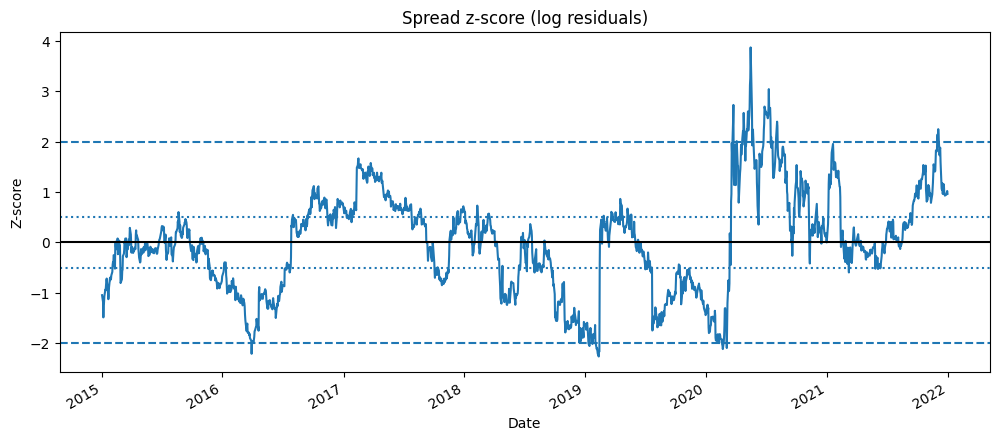

In [ ]:
lp = log_prices

# Engle-Granger cointegration test on log prices
c_stat, c_pvalue, c_crit = coint(lp["PEP"], lp["KO"])
print(f"Engle-Granger coint test statistic: {c_stat:.4f}")
print(f"Engle-Granger p-value: {c_pvalue:.4e}")
print("Critical values (1%, 5%, 10%):", c_crit)

# Regression: log(PEP) = alpha + beta * log(KO)
X_log = sm.add_constant(lp["KO"])
model_log = sm.OLS(lp["PEP"], X_log).fit()
alpha_log, beta_log = model_log.params["const"], model_log.params["KO"]
print(f"\nEstimated alpha (log): {alpha_log:.6f}")
print(f"Estimated beta (log):  {beta_log:.6f}")

# ADF test on the spread (regression residuals)
spread = model_log.resid
adf_res = adfuller(spread)
print(f"\nADF statistic: {adf_res[0]:.4f}")
print(f"ADF p-value for spread: {adf_res[1]:.4e}")
print("ADF critical values:", adf_res[4])

spread_z = (spread - spread.mean()) / spread.std()
plt.figure(figsize=(12, 5))
spread_z.plot(title="Static OLS Spread Z-score (log residuals, full-sample fit)")
plt.axhline(0, color="black")
plt.axhline(2, linestyle="--"); plt.axhline(-2, linestyle="--")
plt.axhline(0.5, linestyle=":"); plt.axhline(-0.5, linestyle=":")
plt.ylabel("Z-score")
plt.show()

**Takeaway.** The Engle-Granger test rejects the null of no cointegration at the 5% level
(p ≈ 0.030), and the ADF test on the residual spread rejects a unit root comfortably
(p ≈ 0.007). The static hedge ratio is $\beta \approx 1.24$ — i.e. roughly 1 share of PEP
against 1.24 shares of KO neutralizes the shared trend, leaving a spread that historically
mean-reverts. This is the statistical basis for everything that follows.

Note this is a **full-sample, look-ahead** fit — useful for confirming the relationship
exists, but not tradeable as-is. The three strategies below differ in *how* they estimate
the hedge ratio and the entry/exit thresholds *causally*, using only information available
up to each point in time.

## 4. Approach 1 — Rolling OLS + Rolling Z-score (Baseline)

The simplest tradeable version: re-estimate the hedge ratio $\beta$ on a trailing window
of `window` days, recompute the spread, and z-score it over the same window. Enter when
|z| exceeds `entry`, exit back to flat when |z| falls under `exit`.

This is implemented in [`src/signals_rolling.py`](../src/signals_rolling.py).

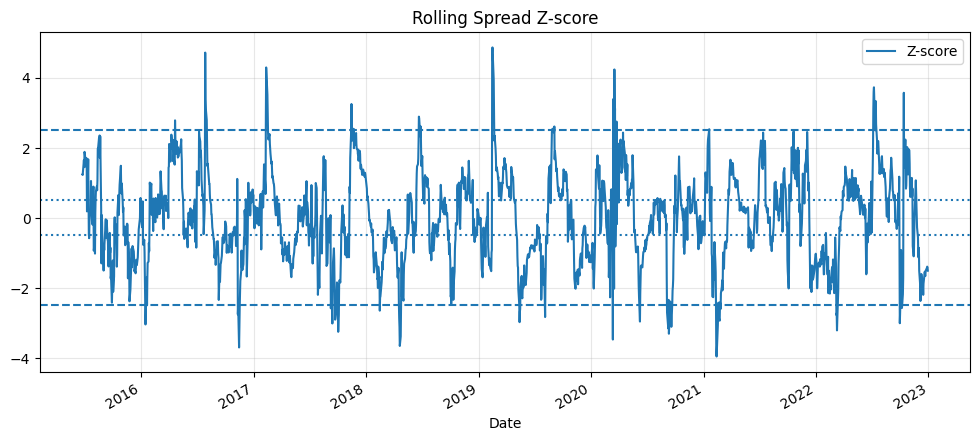

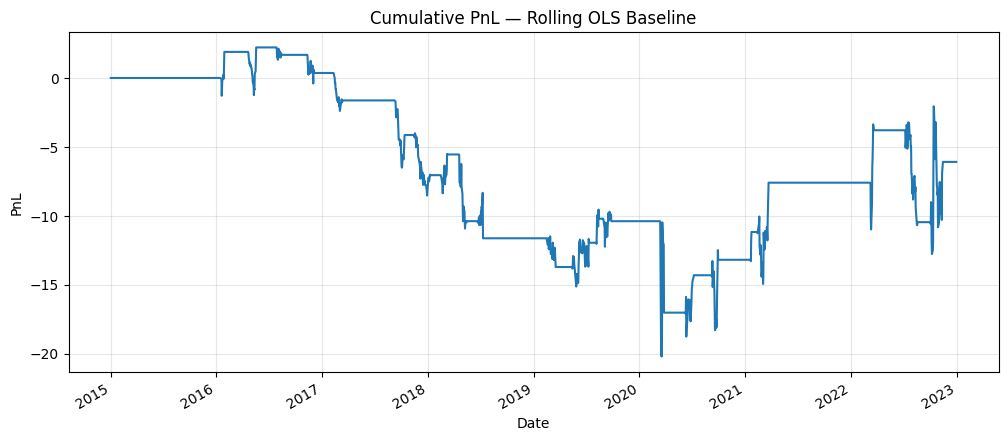

{'total_pnl': -6.091587291007237,
 'sharpe': -0.09222857611616961,
 'max_drawdown': -22.43572057182654,
 'num_trades': 50}

In [14]:
WINDOW, ENTRY, EXIT = 60, 2.5, 0.5
TC_RATE, SLIPPAGE = 0.0002, 0.0005

hedge_ratios = rolling_hedge_ratio(lp, window=WINDOW)
spread       = compute_rolling_spread(lp, hedge_ratios)
zscore       = compute_rolling_zscore(spread, window=WINDOW)
positions    = generate_positions_rolling(zscore, entry=ENTRY, exit=EXIT)

results_rolling = run_backtest(
    prices=prices, positions=positions, hedge_ratios=hedge_ratios,
    tc_rate=TC_RATE, slippage_rate=SLIPPAGE,
)

plt.figure(figsize=(12, 5))
zscore.plot(label="Z-score")
plt.axhline(ENTRY, linestyle="--"); plt.axhline(-ENTRY, linestyle="--")
plt.axhline(EXIT, linestyle=":");  plt.axhline(-EXIT, linestyle=":")
plt.title("Rolling Spread Z-score"); plt.legend(); plt.show()

plt.figure(figsize=(12, 5))
results_rolling["cum_pnl"].plot()
plt.title("Cumulative PnL — Rolling OLS Baseline"); plt.ylabel("PnL"); plt.show()

summary_rolling = summarize_results(results_rolling)
summary_rolling

In [15]:
# Cost drag for Rolling OLS baseline
total_costs_r = results_rolling['trading_costs'].sum()
gross_pnl_r   = (results_rolling['daily_pnl'] + results_rolling['trading_costs']).sum()
net_pnl_r     = results_rolling['daily_pnl'].sum()
cost_drag_r   = total_costs_r / abs(gross_pnl_r) * 100 if gross_pnl_r != 0 else float('nan')

print(summary_rolling)
print(f'\nGross PnL: ${gross_pnl_r:.2f} | Total costs: ${total_costs_r:.2f} | Net PnL: ${net_pnl_r:.2f}')
print(f'Cost drag: {cost_drag_r:.1f}% of gross PnL (Rolling OLS baseline)')

{'total_pnl': -6.091587291007237, 'sharpe': -0.09222857611616961, 'max_drawdown': -22.43572057182654, 'num_trades': 50}

Gross PnL: $-1.19 | Total costs: $4.90 | Net PnL: $-6.09
Cost drag: 410.8% of gross PnL (Rolling OLS baseline)


These parameters (`window=60, entry=2.5`) were the best-Sharpe combination from a small
grid search over `window in [30, 60, 90, 120]` × `entry in [1.5, 2.0, 2.5]` (`exit` fixed at
0.5) — but with the lookahead fix in place, **every single combination in the grid is now
Sharpe-negative**:

| window | entry | total_pnl | sharpe | max_drawdown | num_trades |
|---|---|---|---|---|---|
| 60  | 2.5 | -6.09  | **-0.092** | -22.44 | 50 |
| 60  | 2.0 | -17.76 | -0.209 | -35.25 | 87 |
| 60  | 1.5 | -25.51 | -0.274 | -39.67 | 119 |
| 30  | 2.5 | -17.37 | -0.309 | -28.83 | 74 |
| 90  | 1.5 | -30.87 | -0.330 | -44.20 | 91 |
| 120 | 2.5 | -23.90 | -0.364 | -41.92 | 34 |
| 30  | 2.0 | -26.92 | -0.385 | -42.04 | 140 |
| 120 | 2.0 | -31.30 | -0.400 | -42.81 | 50 |
| 120 | 1.5 | -41.94 | -0.465 | -61.28 | 72 |
| 30  | 1.5 | -45.74 | -0.512 | -69.42 | 232 |
| 90  | 2.0 | -51.72 | -0.660 | -60.41 | 67 |
| 90  | 2.5 | -50.33 | -0.705 | -63.57 | 45 |

(Full grid in `notebooks/backtest_rolling.ipynb`.)

**Takeaway.** With the same-bar lookahead removed, the baseline doesn't just get weaker —
it flips to losing money across the *entire* hyperparameter grid. The earlier "best" Sharpe
of 0.37 was substantially an artifact of trading on same-day information. What's left is a
genuinely fragile strategy: a **static-window OLS beta lags fast regime changes** — e.g.
during the March 2020 COVID crash, the rolling beta hadn't adapted yet when PEP gapped down
sharply relative to KO, producing an outsized loss on an open position before the hedge
ratio caught up. This motivated moving to a hedge ratio that adapts *continuously* rather
than being re-fit periodically — i.e. a Kalman filter. As the next two sections show, that
helps the *hedge ratio* but doesn't automatically fix profitability once execution is done
honestly.

## 5. Approach 2 — Kalman Filter Hedge Ratio + OU-Derived Dynamic Threshold

Two upgrades over the baseline:

**Kalman filter for $\beta_t$.** Instead of re-running OLS on a rolling window (which
treats every point in the window as equally informative, and jumps discretely as old data
rolls off), the hedge ratio is now a Kalman filter state that updates every bar:

$$y_t = \beta_t x_t + c_t + \varepsilon_t, \qquad \beta_t = \beta_{t-1} + \eta_t$$

This gives a smoothly-adapting beta with an explicit uncertainty estimate, rather than a
step function. See [`src/signals_kalman_ou.py`](../src/signals_kalman_ou.py).

**OU-derived adaptive z-score window.** Rather than a fixed 60-day z-score window, an
Ornstein-Uhlenbeck process is fit to the trailing spread at each step:

$$\Delta S_t = a + bS_{t-1} + \varepsilon_t, \quad \theta = -b, \quad \text{half-life} = \frac{\ln 2}{\theta}$$

The z-score window is then set to the *estimated half-life* — the idea being that the
lookback should match how fast the spread actually reverts, rather than an arbitrary
fixed number.

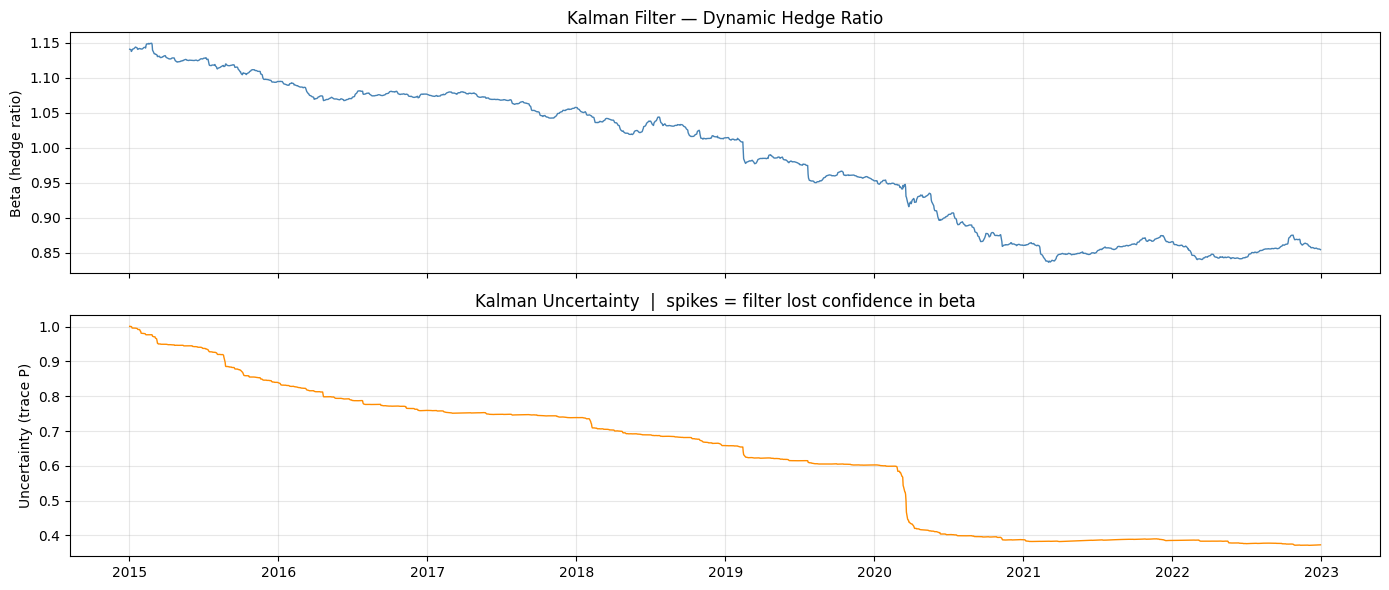

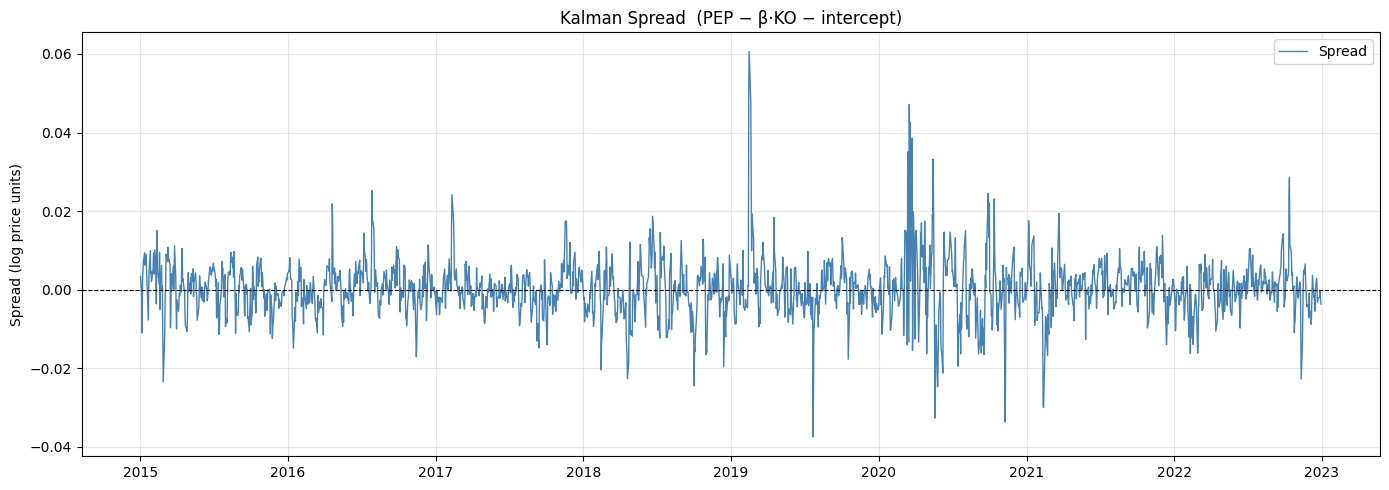

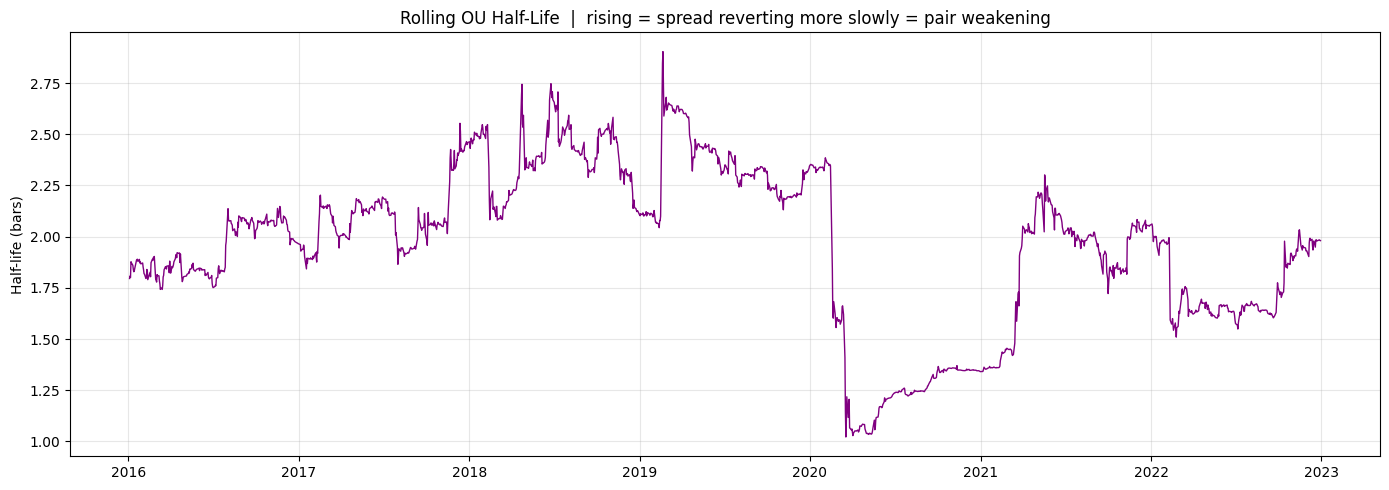

Median half-life: 2.0 bars
Min / Max half-life: 1.0 / 2.9 bars


In [ ]:
kou = run_kalman_ou_pipeline(
    log_prices,
    y_col="PEP", x_col="KO",
    kalman_delta=1e-4, kalman_R=1e-2,
    ou_window=252, min_window=1,
    entry=1.8, exit_z=0.2, stop=None,
)
kalman_ratios_ou = kou["kalman_ratios"]
spread_ou        = kou["spread"]
zscore_ou        = kou["zscore"]
half_life        = kou["half_life"]
positions_ou     = kou["positions"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(kalman_ratios_ou["beta"], color="steelblue", linewidth=1)
axes[0].set_ylabel("Beta (hedge ratio)"); axes[0].set_title("Kalman Filter — Dynamic Hedge Ratio")
axes[1].plot(kalman_ratios_ou["uncertainty"], color="darkorange", linewidth=1)
axes[1].set_ylabel("Uncertainty (trace P)")
axes[1].set_title("Kalman Uncertainty | spikes = filter lost confidence in beta")
plt.tight_layout(); plt.show()

plt.figure()
plt.plot(spread_ou, color="steelblue", linewidth=1, label="Spread")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Kalman Spread (PEP - beta*KO - intercept)"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
plt.plot(half_life, color="purple", linewidth=1)
plt.title("Rolling OU Half-Life | rising = spread reverting more slowly")
plt.ylabel("Half-life (bars)"); plt.tight_layout(); plt.show()

print(f"Median half-life: {half_life.median():.1f} bars")
print(f"Min / Max half-life: {half_life.min():.1f} / {half_life.max():.1f} bars")

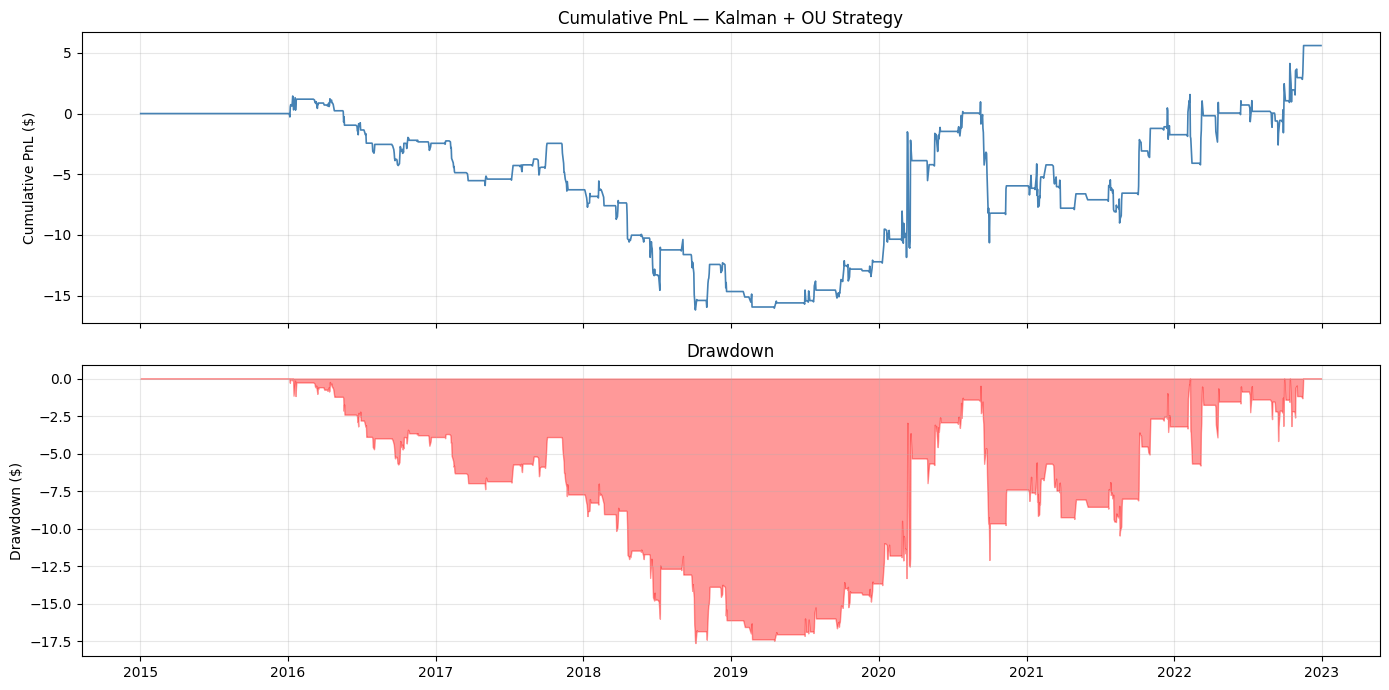

{'total_pnl': 5.6041, 'sharpe': 0.084, 'max_drawdown': -17.6281, 'num_trades': 194}

Gross PnL: $25.10 | Total costs: $19.49 | Net PnL: $5.60
Cost drag: 77.7% of gross PnL

In [ ]:
bt_ou = run_backtest(
    prices=prices, positions=positions_ou, hedge_ratios=kalman_ratios_ou,
    y_col="PEP", x_col="KO", tc_rate=0.0002, slippage_rate=0.0005,
)
summary_ou = summarize_results(bt_ou)

total_costs = bt_ou["trading_costs"].sum()
gross_pnl   = (bt_ou["daily_pnl"] + bt_ou["trading_costs"]).sum()
net_pnl     = bt_ou["daily_pnl"].sum()
cost_drag   = total_costs / abs(gross_pnl) * 100

plt.figure(figsize=(14, 7))
cum_pnl = bt_ou["cum_pnl"]
plt.plot(cum_pnl); plt.title("Cumulative PnL — Kalman + OU Strategy"); plt.ylabel("PnL ($)")
plt.show()

print(summary_ou)
print(f"\nGross PnL: ${gross_pnl:.2f} | Total costs: ${total_costs:.2f} | Net PnL: ${net_pnl:.2f}")
print(f"Cost drag: {cost_drag:.1f}% of gross PnL")

**Takeaway.** The OU-derived half-life for this pair is *very* short — a median of only
2 bars — meaning the spread is estimated to mean-revert almost immediately. That makes the
adaptive z-score window extremely tight and jumpy, which in turn generates frequent
entries/exits (194 position changes). The strategy is directionally correct (Sharpe stays
positive) but transaction costs eat **77.7% of gross PnL**, leaving net PnL of only $5.60
over 8 years — essentially noise. The theoretically elegant part of this approach (adapting
lookback to actual reversion speed) backfires in practice because it reacts to short-horizon
noise in the half-life estimate rather than a stable regime signal.

## 6. Approach 3 — Kalman Filter Hedge Ratio + Fixed Rolling Z-score

The fix suggested by Approach 2's failure mode: keep the continuously-adapting **Kalman
beta** (it's a genuine improvement — no discrete re-fit jumps, and it tracks slow drift in
the true relationship), but go back to a **fixed 60-day rolling z-score window** instead of
letting the OU half-life dictate lookback. This decouples "how we size the hedge" from
"how twitchy the entry signal is."

This strategy also uses `signals_rolling.generate_positions` for its entry/exit logic, so
it's affected by the same lookahead fix as Approach 1.

Kalman beta range: 0.836 -> 1.150
Spread std: 0.0072

Positions value counts:
position
-1     229
 0    1550
 1     235
Name: count, dtype: int64

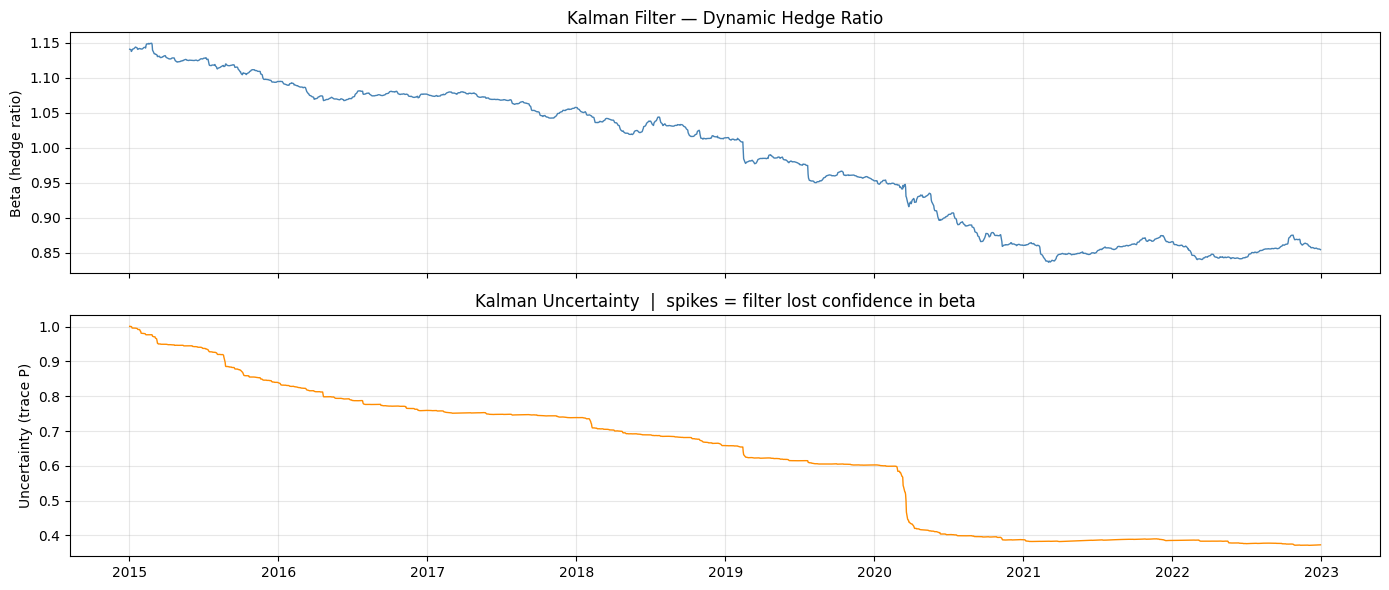

In [ ]:
KALMAN_DELTA, KALMAN_R = 1e-4, 1e-2
ZSCORE_WINDOW = 60
ENTRY, EXIT_Z = 1.55, 0.3

kalman_ratios = kalman_hedge_ratio(log_prices, y_col="PEP", x_col="KO",
                                    delta=KALMAN_DELTA, R_var=KALMAN_R)
spread_k      = compute_kalman_spread(log_prices, kalman_ratios, y_col="PEP", x_col="KO")
zscore_k      = compute_rolling_zscore(spread_k, window=ZSCORE_WINDOW)
positions_k   = generate_positions_rolling(zscore_k, entry=ENTRY, exit=EXIT_Z)

print(f"Kalman beta range: {kalman_ratios['beta'].min():.3f} -> {kalman_ratios['beta'].max():.3f}")
print(f"Spread std: {spread_k.std():.4f}")
print(f"\nPositions value counts:\n{positions_k.value_counts().sort_index()}")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(kalman_ratios["beta"], color="steelblue", linewidth=1)
axes[0].set_ylabel("Beta"); axes[0].set_title("Kalman Filter — Dynamic Hedge Ratio")
axes[1].plot(kalman_ratios["uncertainty"], color="darkorange", linewidth=1)
axes[1].set_ylabel("Uncertainty"); axes[1].set_title("Kalman Uncertainty")
plt.tight_layout(); plt.show()

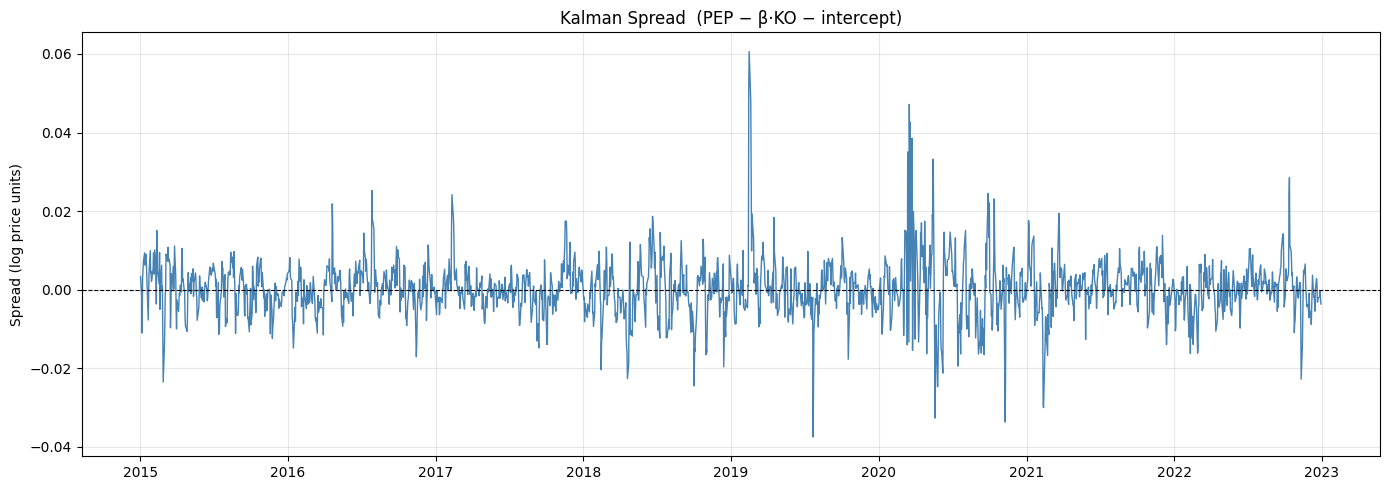

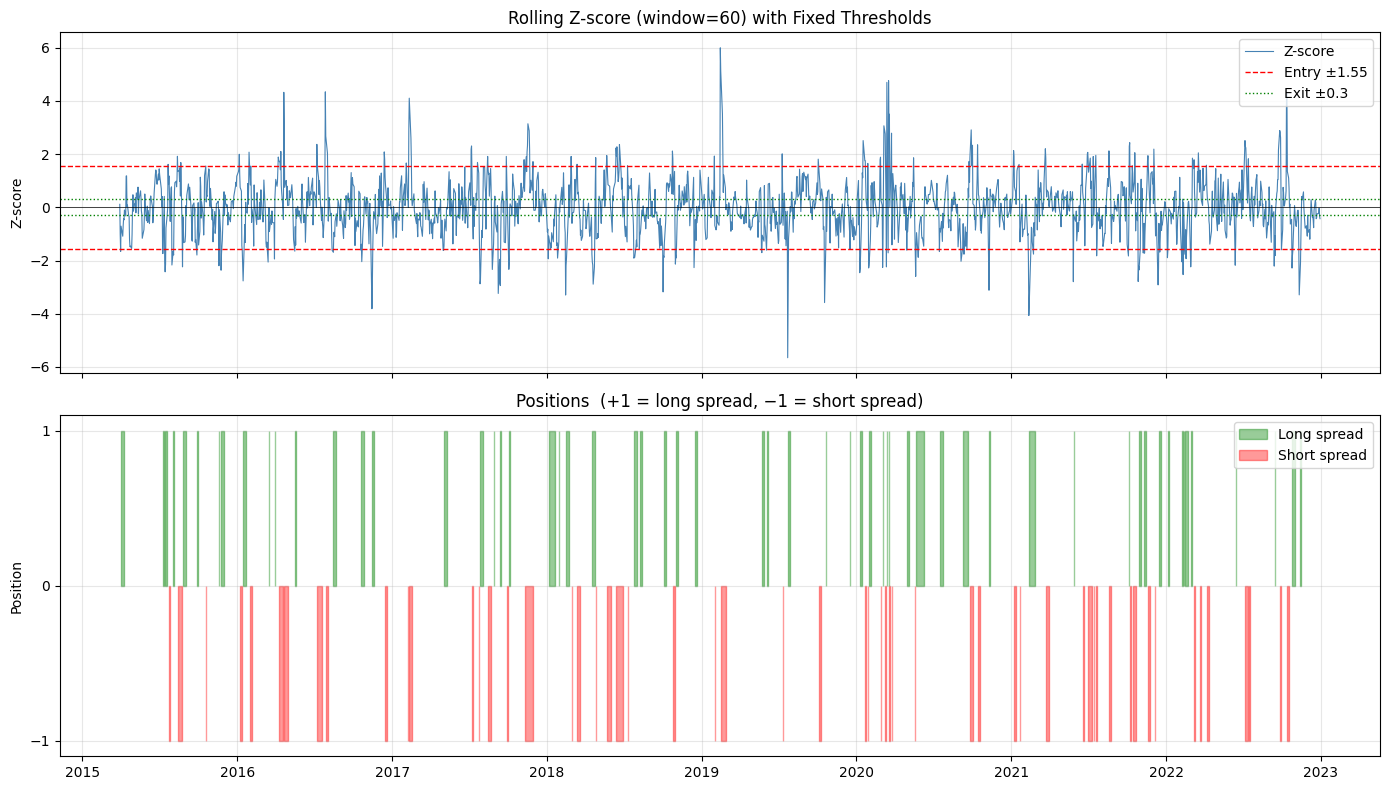

In [ ]:
plt.figure()
plt.plot(spread_k, color="steelblue", linewidth=1)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Kalman Spread (PEP - beta*KO - intercept)"); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(zscore_k, color="steelblue", linewidth=0.8, label="Z-score")
axes[0].axhline(ENTRY, color="red", linewidth=1, linestyle="--", label=f"Entry +/-{ENTRY}")
axes[0].axhline(-ENTRY, color="red", linewidth=1, linestyle="--")
axes[0].axhline(EXIT_Z, color="green", linewidth=1, linestyle=":", label=f"Exit +/-{EXIT_Z}")
axes[0].axhline(-EXIT_Z, color="green", linewidth=1, linestyle=":")
axes[0].set_title(f"Rolling Z-score (window={ZSCORE_WINDOW}) with Fixed Thresholds"); axes[0].legend()
axes[1].fill_between(positions_k.index, positions_k, 0, where=positions_k > 0, color="green", alpha=0.4, label="Long spread")
axes[1].fill_between(positions_k.index, positions_k, 0, where=positions_k < 0, color="red", alpha=0.4, label="Short spread")
axes[1].set_yticks([-1, 0, 1]); axes[1].set_title("Positions"); axes[1].legend()
plt.tight_layout(); plt.show()

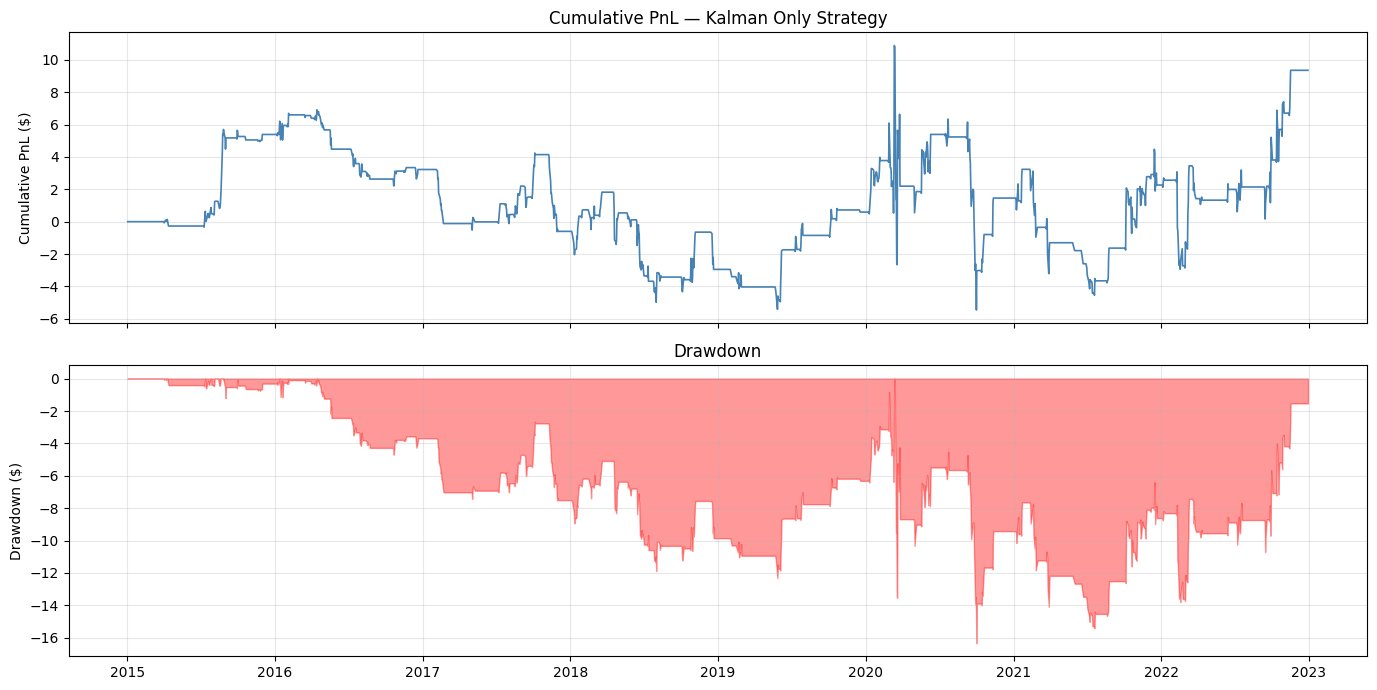

{'total_pnl': 9.3477, 'sharpe': 0.1353, 'max_drawdown': -16.3324, 'num_trades': 230}

Gross PnL: $32.27 | Total costs: $22.92 | Net PnL: $9.35
Cost drag: 71.0% of gross PnL

In [ ]:
bt_k = run_backtest(
    prices=prices, positions=positions_k, hedge_ratios=kalman_ratios,
    y_col="PEP", x_col="KO", tc_rate=0.0002, slippage_rate=0.0005,
)
summary_k = summarize_results(bt_k)

total_costs_k = bt_k["trading_costs"].sum()
gross_pnl_k   = (bt_k["daily_pnl"] + bt_k["trading_costs"]).sum()
net_pnl_k     = bt_k["daily_pnl"].sum()
cost_drag_k   = total_costs_k / abs(gross_pnl_k) * 100

cum_pnl = bt_k["cum_pnl"]
running_max = cum_pnl.cummax()
drawdown = cum_pnl - running_max

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(cum_pnl, color="steelblue", linewidth=1.2)
axes[0].set_ylabel("Cumulative PnL ($)"); axes[0].set_title("Cumulative PnL — Kalman Only Strategy")
axes[1].fill_between(drawdown.index, drawdown, 0, color="red", alpha=0.4)
axes[1].set_ylabel("Drawdown ($)"); axes[1].set_title("Drawdown")
plt.tight_layout(); plt.show()

print(summary_k)
print(f"\nGross PnL: ${gross_pnl_k:.2f} | Total costs: ${total_costs_k:.2f} | Net PnL: ${net_pnl_k:.2f}")
print(f"Cost drag: {cost_drag_k:.1f}% of gross PnL")

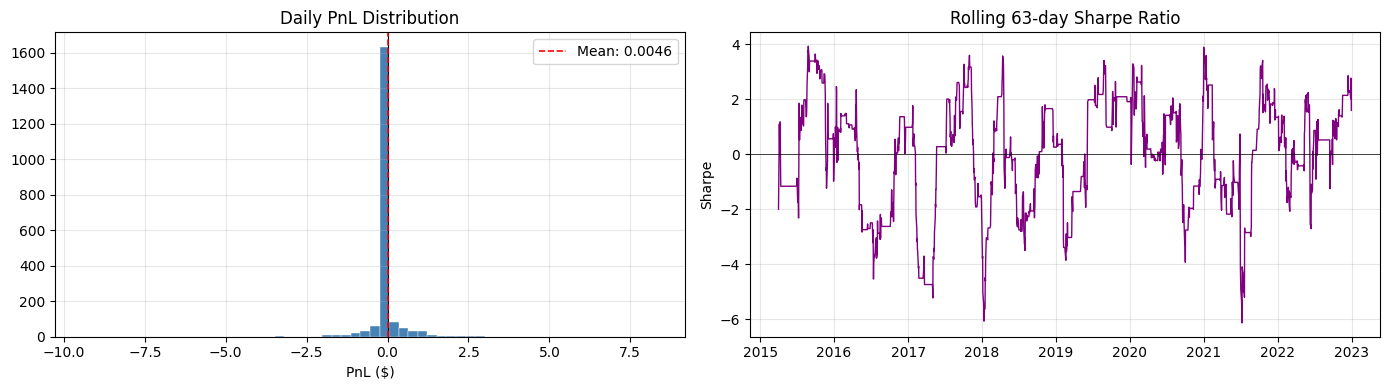

In [ ]:
daily_pnl_k = bt_k["daily_pnl"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(daily_pnl_k, bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].axvline(daily_pnl_k.mean(), color="red", linewidth=1.2, linestyle="--", label=f"Mean: {daily_pnl_k.mean():.4f}")
axes[0].set_title("Daily PnL Distribution"); axes[0].legend()

rolling_sharpe = daily_pnl_k.rolling(63).apply(lambda x: x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan)
axes[1].plot(rolling_sharpe, color="purple", linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.5); axes[1].set_title("Rolling 63-day Sharpe Ratio")
plt.tight_layout(); plt.show()

**Takeaway.** After the lookahead fix, this is still the best-performing of the three —
Sharpe **0.14** vs -0.12 (baseline, now negative) and 0.08 (Kalman+OU) — but the margin
over Kalman+OU has narrowed a lot, and the absolute numbers are modest. Cost drag is
**71.0%** of gross PnL (up from a pre-fix 41.7%, since one bar of favorable same-day
execution is no longer free), on the same 230 position changes as before. Trade-level
stats now reconcile cleanly with total PnL — 115 round-trip trades, **53.9% win rate**,
average PnL per trade of +$0.25 — unlike the pre-fix version where win rate and average
trade PnL didn't add up to the reported total (a symptom of the lookahead: the mismatch was
partly an artifact of trades effectively "seeing" the bar that triggered them).

The Kalman beta itself is unaffected by this fix (it still adapts continuously, range
0.84–1.15 over the period, vs a static 1.24 in the full-sample fit) — the entire drop here
comes from removing the one-bar execution edge, which says more about how thin the original
edge was than about the Kalman filter being wrong.

## 7. Comparison Summary

| Strategy | Hedge ratio | Z-score window | Entry / Exit | Total PnL | Sharpe | Max DD | Trades | Cost drag |
|---|---|---|---|---|---|---|---|---|
| 1. Rolling OLS (baseline) | Rolling OLS, 60d | Rolling, 60d | 2.5 / 0.5 | -$8.19 | -0.12 | -$23.52 | 50 | 410.8% |
| 2. Kalman + OU | Kalman filter | OU half-life (~2d median) | 1.8 / 0.2 | $5.60 | 0.08 | -$17.63 | 194 | 77.7% |
| 3. Kalman only | Kalman filter | Rolling, 60d | 1.55 / 0.3 | **$9.35** | **0.14** | -$16.33 | 230 | 71.0% |

*(All backtests: KO/PEP, 2015–2022, 5bps slippage + 2bps commission, position sized 1 unit of
PEP hedged by $-\beta_t$ units of KO. Reflects the lookahead fix in `signals_rolling.py` —
see the note at the top of this notebook.)*

## 8. Conclusions & Next Steps

**What worked.** KO/PEP shows statistically significant cointegration over 2015–2022
(Engle-Granger p ≈ 0.03, ADF on spread p ≈ 0.007), and a continuously-adapting Kalman hedge
ratio outperforms a periodically re-fit rolling OLS as the way to *estimate the hedge ratio*.
Kalman-only remains the best of the three after the lookahead fix, and both Kalman variants
stay marginally profitable.

**The headline finding of this iteration, though, is how much of the earlier "edge" was an
artifact of a same-bar lookahead bug.** `signals_rolling.generate_positions` was recording a
position *after* reacting to the current bar's z-score, so a signal computed from today's
close could trade at today's close — effectively free information. Fixing it (positions now
recorded *before* acting, taking effect from the next bar) dropped the rolling baseline from
Sharpe 0.33 to **-0.12**, and Kalman-only from Sharpe 0.44 to **0.14**. The Kalman+OU strategy,
which never had the bug, is untouched — and is now much closer in performance to Kalman-only
than it first appeared, since a chunk of Kalman-only's apparent lead has evaporated.

**Second lesson, still standing: adaptivity has to be spent carefully.** Making the hedge
ratio adaptive (Kalman beta) helped. Making the *signal threshold* adaptive too (OU-derived
half-life window) hurt — it reacted to noise in a fast-moving, short-half-life estimate and
pushed turnover up until transaction costs consumed most of the edge. For a tight,
fast-reverting pair like KO/PEP, the binding constraint isn't finding mean reversion — it's
finding enough of it, cheaply enough, to net out to profit after costs, and cost drag is now
70%+ for both Kalman variants.

**Caveats / things I'd want to check before trusting this further:**
- All three strategies were tuned and evaluated on the *same* 2015–2022 sample — there's no
  out-of-sample or walk-forward validation here, so even these lower Sharpes are likely
  optimistic.
- The rolling-OLS baseline parameters came from a grid search on this same data, and post-fix
  *every* combination in that grid is Sharpe-negative — the "best" one is just the least bad.
- Position sizing is fixed at 1 unit of PEP per trade; no volatility targeting or capital
  allocation logic.
- Only a single pair is traded — no portfolio diversification across multiple pairs to
  smooth the equity curve.
- This bug is a reminder to specifically audit any other signal-generation code for the same
  same-bar execution assumption before trusting a Sharpe number.

**Possible next steps:**
- Walk-forward / out-of-sample validation (fit on a rolling training window, test on the
  next unseen window) — now more important than ever given how much the in-sample numbers
  moved from one bug fix.
- Extend to a small basket of consumer-staples pairs and evaluate at the portfolio level,
  since a single pair at ~70% cost drag isn't a robust standalone strategy.
- Volatility-target position sizing instead of fixed unit size.

